#### Libraries used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [2]:
IN_KAGGLE = os.path.exists('/kaggle/input') 

if IN_KAGGLE :
    # change that to name of folder on kaggle
    DATA_DIR = Path('/kaggle/input/house-prices-advanced-regression-techniques')

else :
    # Path.cwd() <> current working directory
    # parent() <> undo a folder 
    DATA_DIR = Path.cwd().parent / 'datasets'  / 'raw' 

train_data = pd.read_csv( DATA_DIR / 'train.csv')
train_data.shape

(1460, 81)

In [3]:
def summary( df ):

    pd.set_option('display.max.rows' , None)
    pd.set_option('display.max.columns' , None)

    summary_df = pd.DataFrame({'DType' : df.dtypes , 
                  'Count_Null' : df.isnull().sum() ,
                  'Null_Percent' : ( df.isnull().sum() / len(df)) * 100 ,
                  'Unipue' : df.nunique()
                  } )
 
    return summary_df

summary( train_data )

,DType,Count_Null,Null_Percent,Unipue
Id,int64,0,0.000000,1460
MSSubClass,int64,0,0.000000,15
MSZoning,str,0,0.000000,5
LotFrontage,float64,259,17.739726,110
LotArea,int64,0,0.000000,1073
Street,str,0,0.000000,2
Alley,str,1369,93.767123,2
LotShape,str,0,0.000000,4
LandContour,str,0,0.000000,4
Utilities,str,0,0.000000,2


In [4]:
train_data['Alley'] = train_data['Alley'].fillna('Missing')
train_data['Alley'].value_counts()

Alley
Missing    1369
Grvl         50
Pave         41
Name: count, dtype: int64

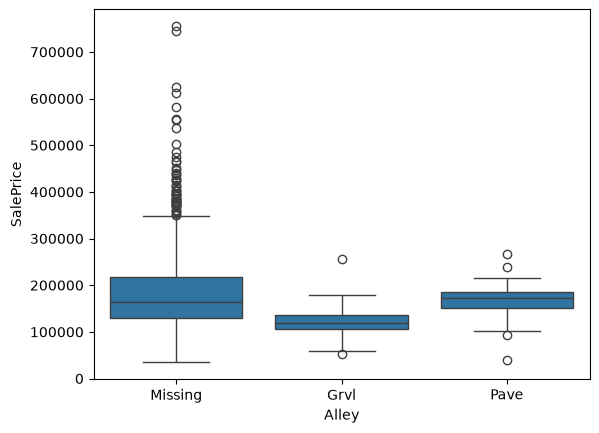

In [5]:
def box_plot_fun( var ):
    sns.boxplot( x= var , y='SalePrice', data = train_data )

box_plot_fun('Alley')

In [6]:
train_data['PoolQC'] = train_data['PoolQC'].fillna('Missing')
train_data['PoolQC'].value_counts() 

PoolQC
Missing    1453
Gd            3
Ex            2
Fa            2
Name: count, dtype: int64

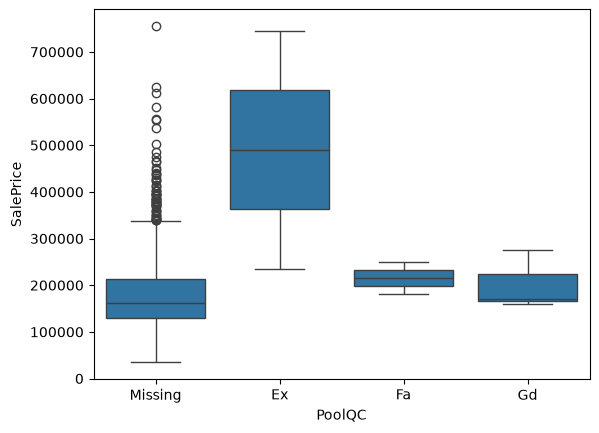

In [7]:
box_plot_fun('PoolQC')

In [8]:
train_data['Fence'] = train_data['Fence'].fillna('Missing')
train_data['Fence'].value_counts()

Fence
Missing    1179
MnPrv       157
GdPrv        59
GdWo         54
MnWw         11
Name: count, dtype: int64

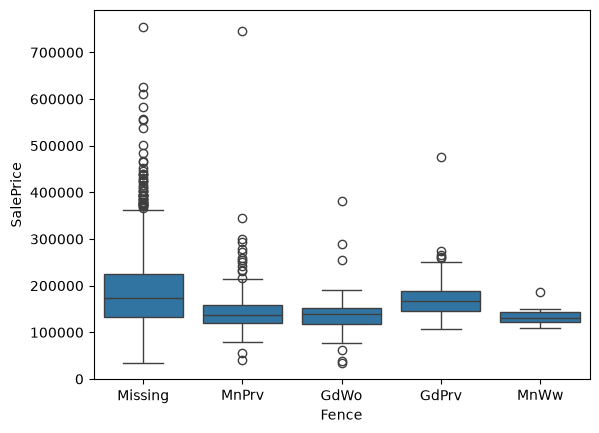

In [9]:
box_plot_fun('Fence')

In [10]:
train_data['MiscFeature'] = train_data['MiscFeature'].fillna('Missing')
train_data['MiscFeature'].value_counts()

MiscFeature
Missing    1406
Shed         49
Gar2          2
Othr          2
TenC          1
Name: count, dtype: int64

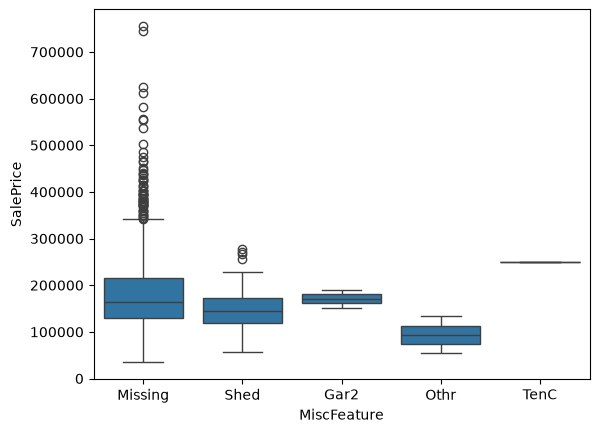

In [11]:
box_plot_fun('MiscFeature')

In [12]:
train_data['MasVnrType'] = train_data['MasVnrType'].fillna('Missing')
train_data['MasVnrType'].value_counts()

MasVnrType
Missing    872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

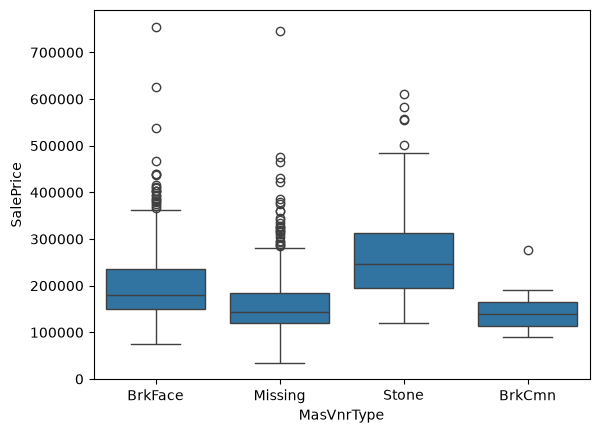

In [13]:
box_plot_fun('MasVnrType')

In [14]:
train_data['FireplaceQu'] = train_data['FireplaceQu'].fillna('Missing')
train_data['FireplaceQu'].value_counts()

FireplaceQu
Missing    690
Gd         380
TA         313
Fa          33
Ex          24
Po          20
Name: count, dtype: int64

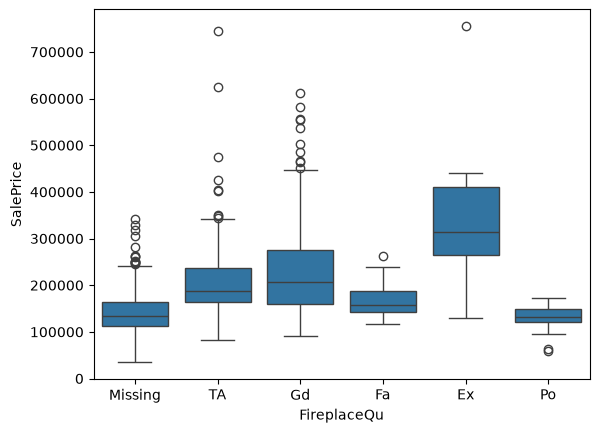

In [15]:
box_plot_fun('FireplaceQu')

In [16]:
train_data = train_data.drop(
['Alley' , 'Fence' , 'MiscFeature' , 'MasVnrType', 'FireplaceQu'] , axis= 1)

train_data.shape

(1460, 76)

### outliers

In [17]:
num_columns = train_data.select_dtypes( include=np.number )
num_columns.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [18]:
train_data['OverallQual'].value_counts() , train_data['OverallCond'].value_counts()

(OverallQual
 5     397
 6     374
 7     319
 8     168
 4     116
 9      43
 3      20
 10     18
 2       3
 1       2
 Name: count, dtype: int64,
 OverallCond
 5    821
 6    252
 7    205
 8     72
 4     57
 3     25
 9     22
 2      5
 1      1
 Name: count, dtype: int64)

In [19]:
train_data['BsmtFullBath'].value_counts() , train_data['BsmtHalfBath'].value_counts()

(BsmtFullBath
 0    856
 1    588
 2     15
 3      1
 Name: count, dtype: int64,
 BsmtHalfBath
 0    1378
 1      80
 2       2
 Name: count, dtype: int64)

In [20]:
train_data['FullBath'].value_counts() , train_data['HalfBath'].value_counts()

(FullBath
 2    768
 1    650
 3     33
 0      9
 Name: count, dtype: int64,
 HalfBath
 0    913
 1    535
 2     12
 Name: count, dtype: int64)

In [21]:
train_data['BedroomAbvGr'].value_counts() , train_data['KitchenAbvGr'].value_counts()

(BedroomAbvGr
 3    804
 2    358
 4    213
 1     50
 5     21
 6      7
 0      6
 8      1
 Name: count, dtype: int64,
 KitchenAbvGr
 1    1392
 2      65
 3       2
 0       1
 Name: count, dtype: int64)

In [22]:
train_data['TotRmsAbvGrd'].value_counts() , train_data['Fireplaces'].value_counts()

(TotRmsAbvGrd
 6     402
 7     329
 5     275
 8     187
 4      97
 9      75
 10     47
 11     18
 3      17
 12     11
 2       1
 14      1
 Name: count, dtype: int64,
 Fireplaces
 0    690
 1    650
 2    115
 3      5
 Name: count, dtype: int64)

In [23]:
train_data['GarageCars'].value_counts()

GarageCars
2    824
1    369
3    181
0     81
4      5
Name: count, dtype: int64

- These Columns don't have Any outliers and thay are discrete

In [24]:
cols_for_outliers = num_columns.drop( [ 'Id' , 'MSSubClass' , 'OverallQual' ,
                                      'OverallCond', 'BsmtFullBath', 
                                      'FullBath' , 'HalfBath' , 'BedroomAbvGr',
                                      'KitchenAbvGr' , 'TotRmsAbvGrd' , 
                                      'Fireplaces' , 'GarageCars' , 
                                     ] , axis = 1 )
cols_for_outliers.columns

Index(['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

#### Outliers Detection and Remove

In [ ]:
def all_columns_with_price(train_data):  

    batch_size = 3
    cols_list = list(cols_for_outliers.columns)

    for i in range(0, len(cols_list), batch_size):

        current_batch = cols_list[i : i + batch_size]

        fig, axes = plt.subplots(1, len(current_batch), figsize=(20, 6))

        if len(current_batch) == 1:
            axes = [axes]

        for j, col in enumerate(current_batch):
            sns.scatterplot(
                data=train_data, x=col, y="SalePrice", ax=axes[j], alpha=0.6
            )
            axes[j].set_title(f"{col} vs SalePrice", fontsize=10)

        plt.tight_layout()
        plt.show()


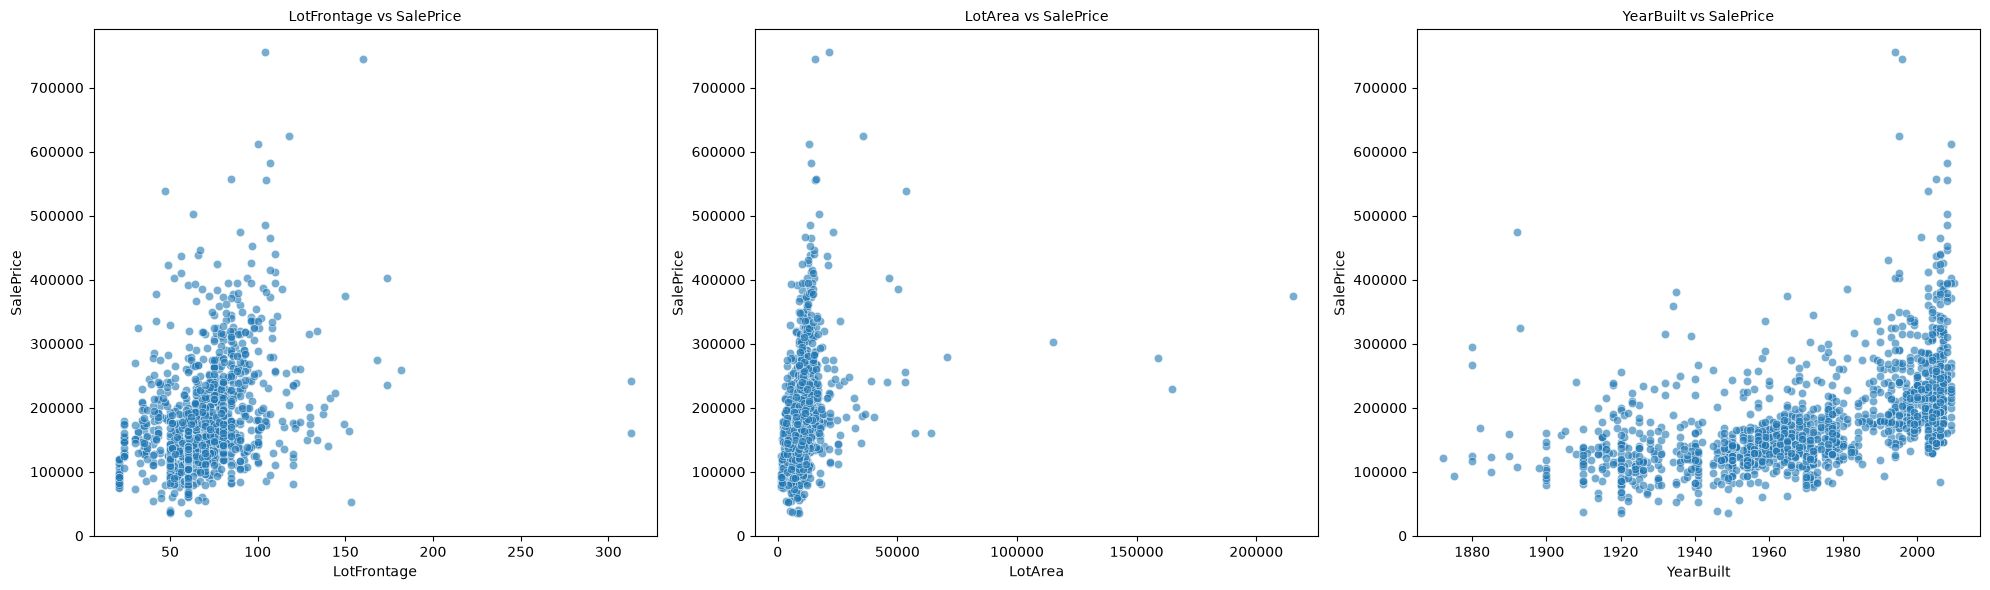

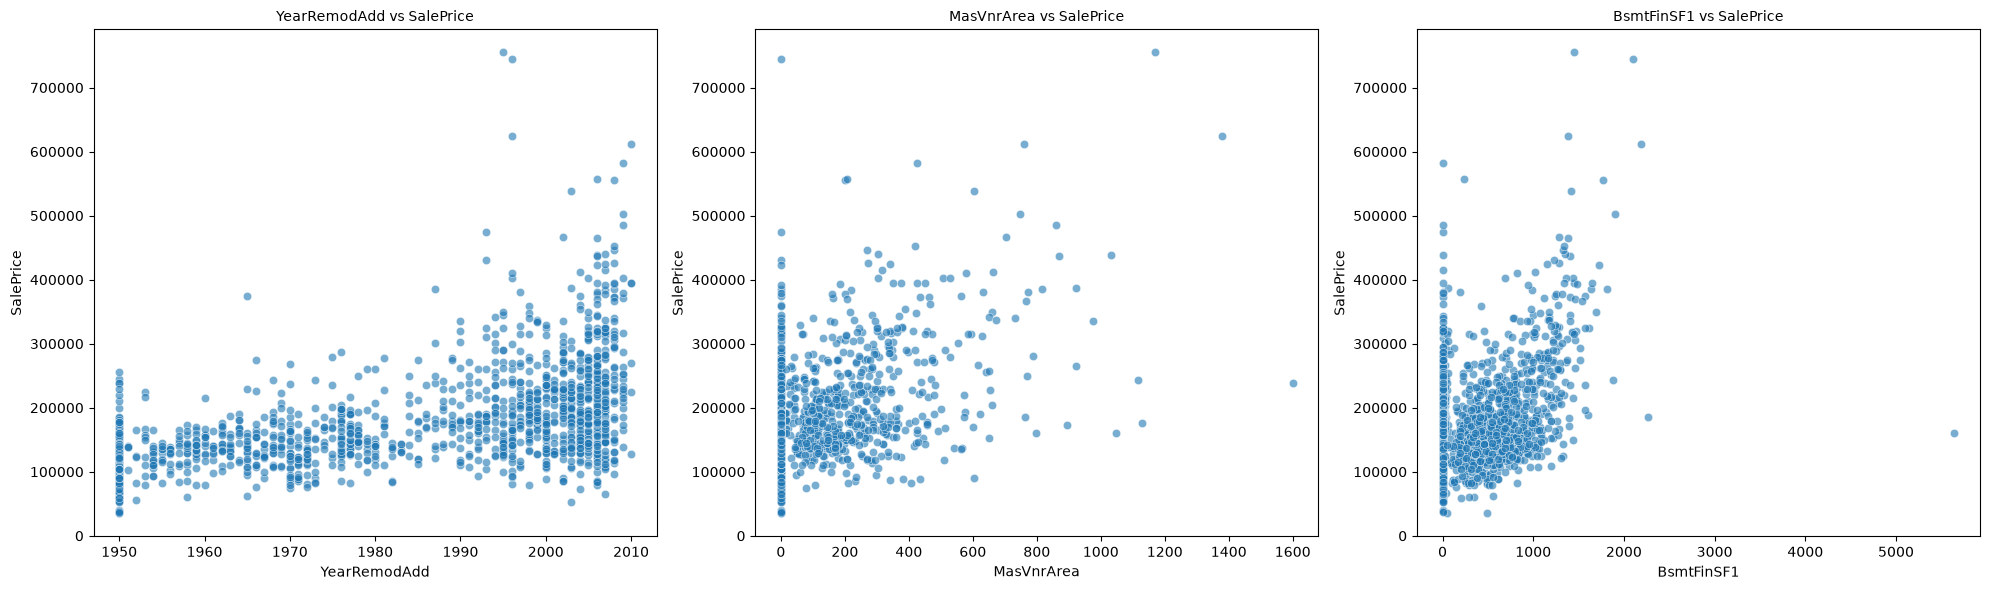

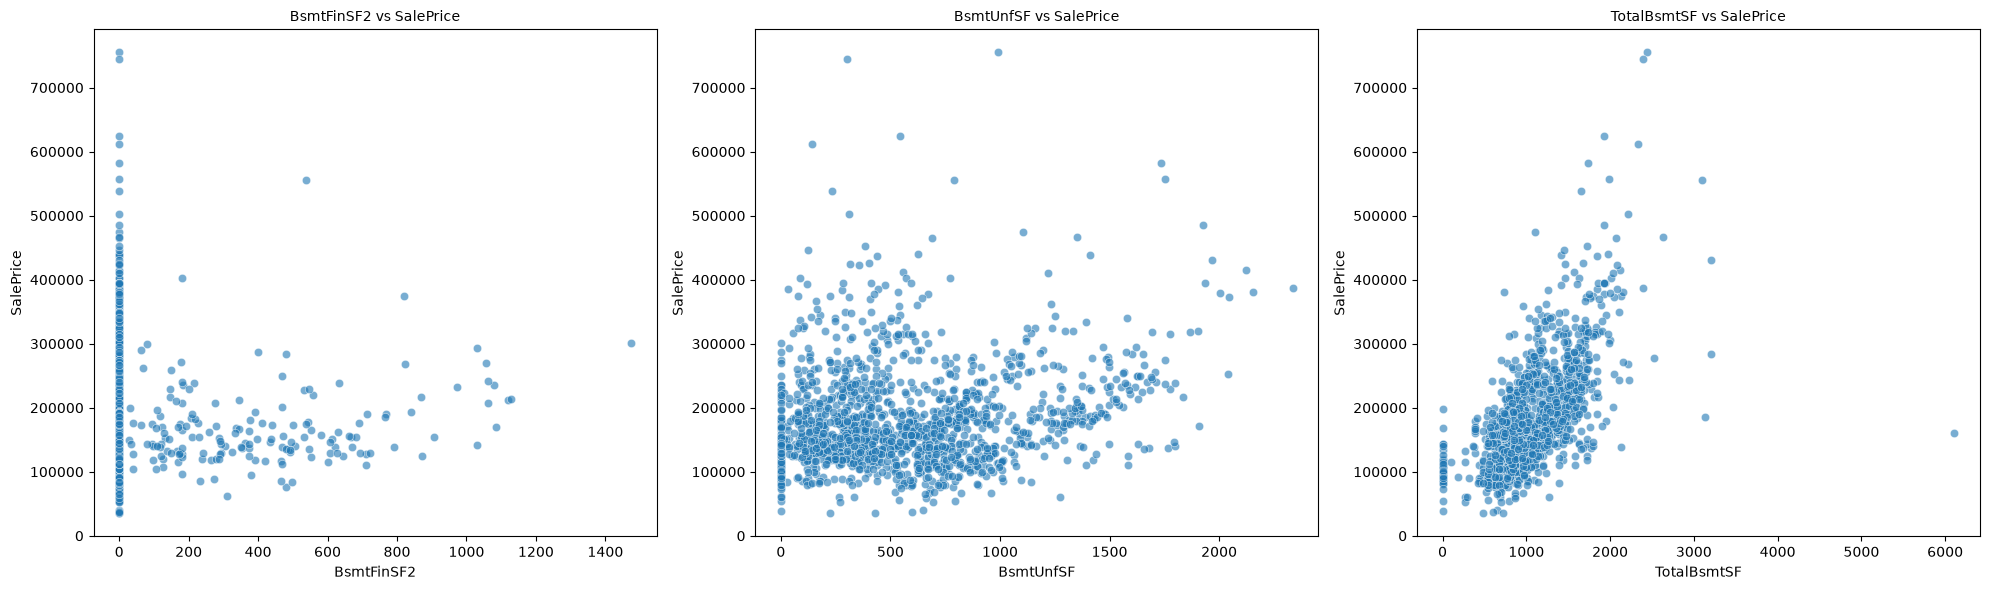

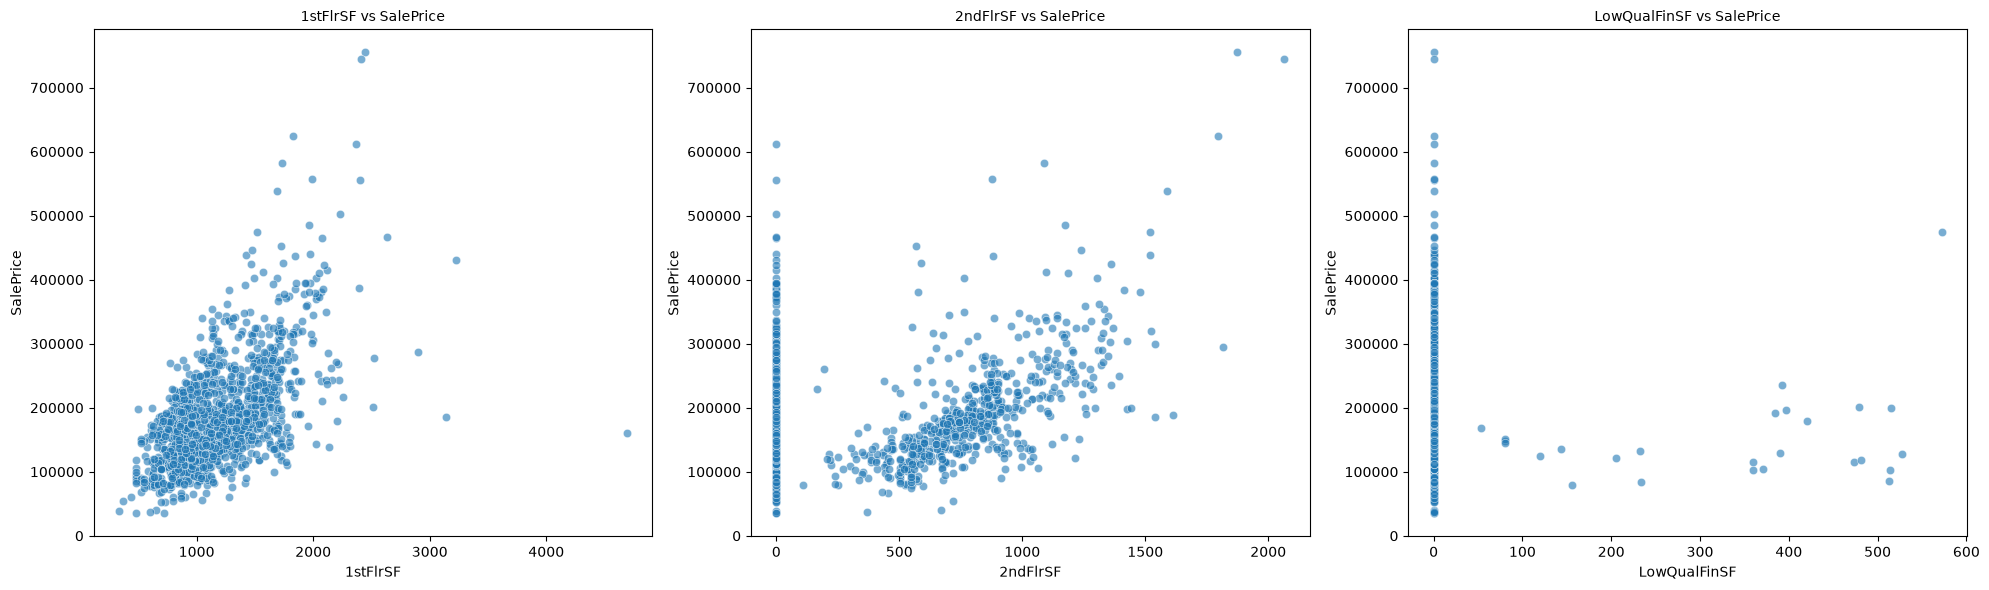

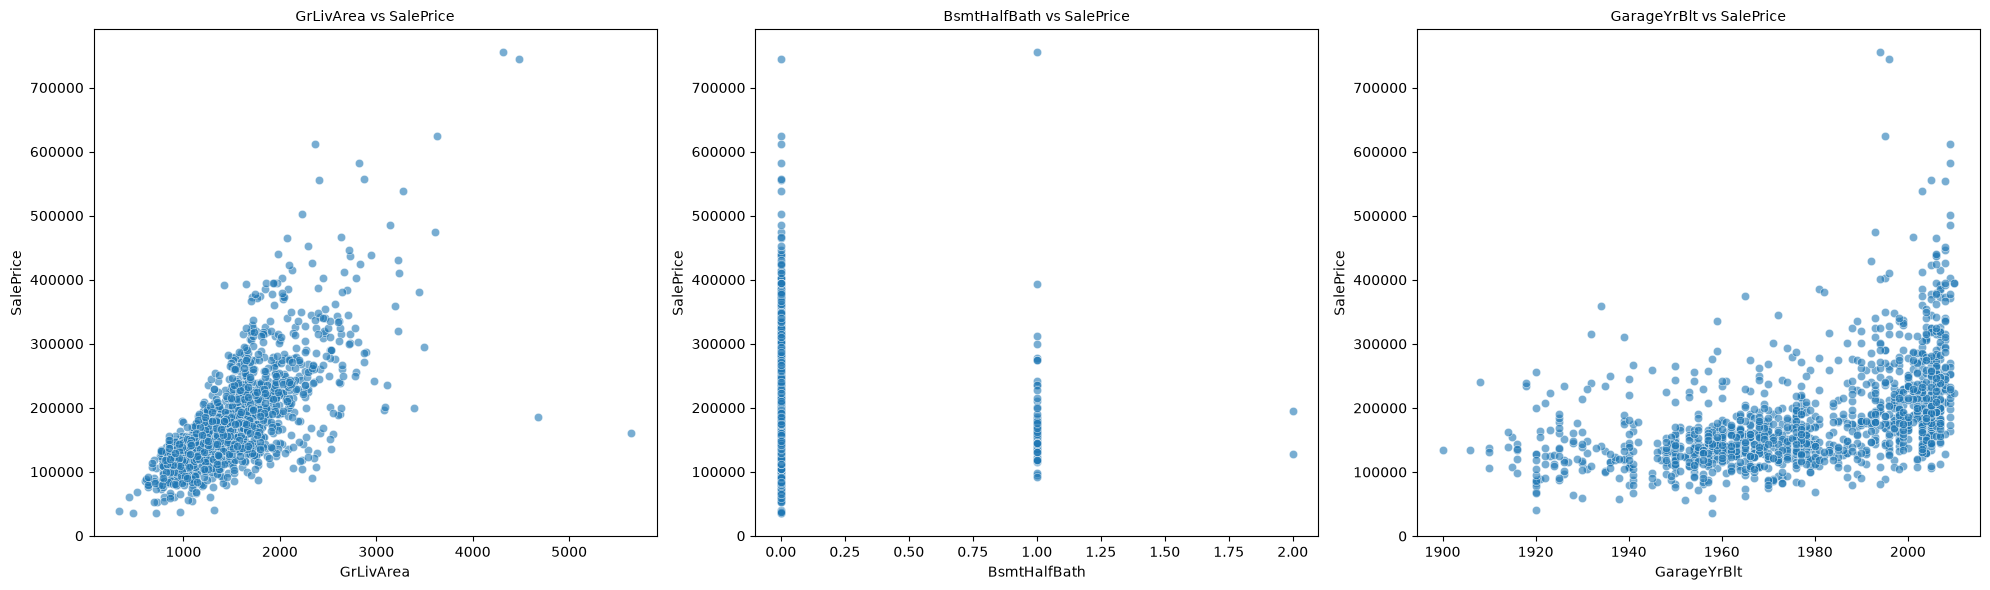

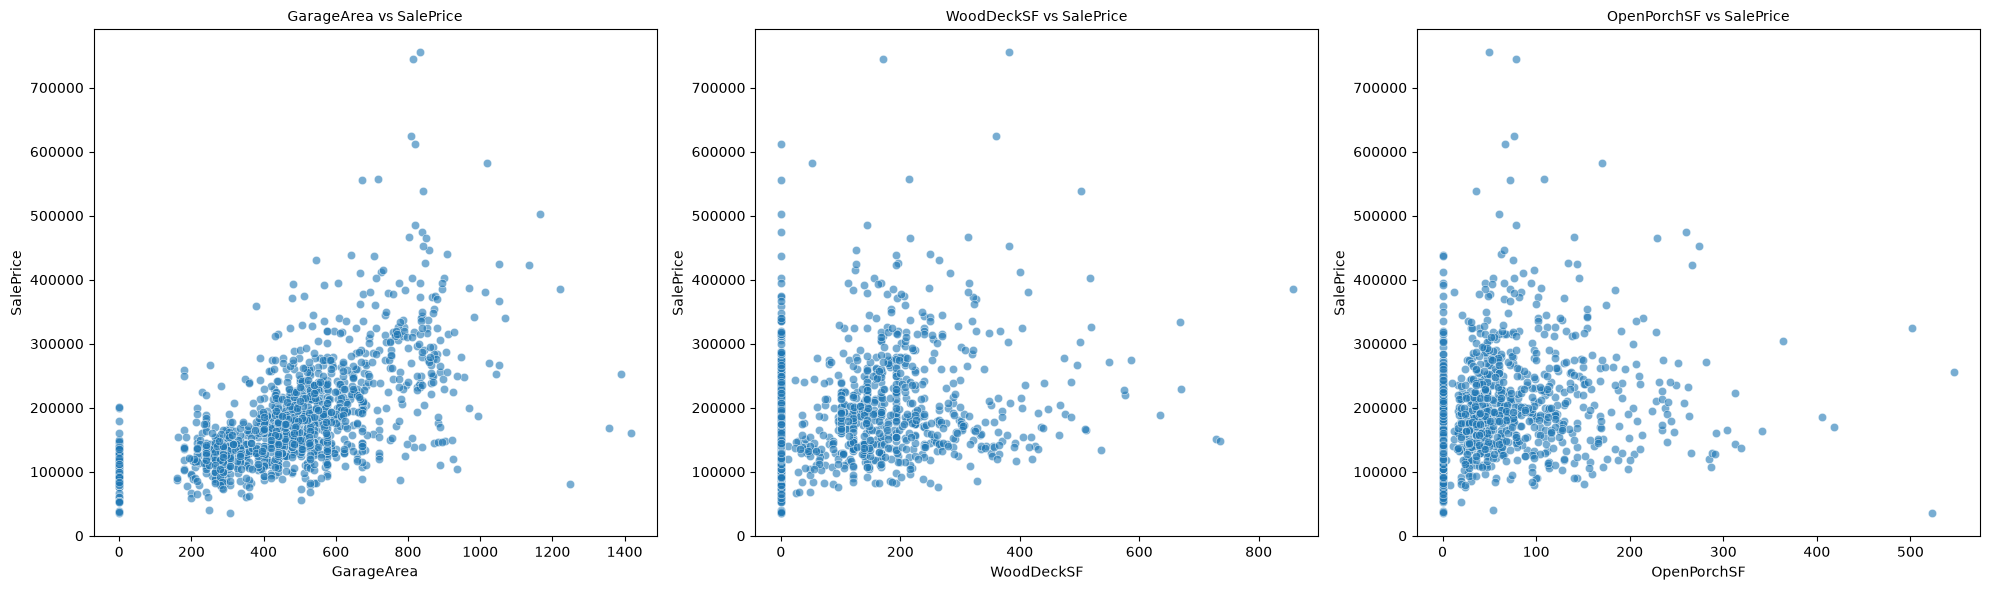

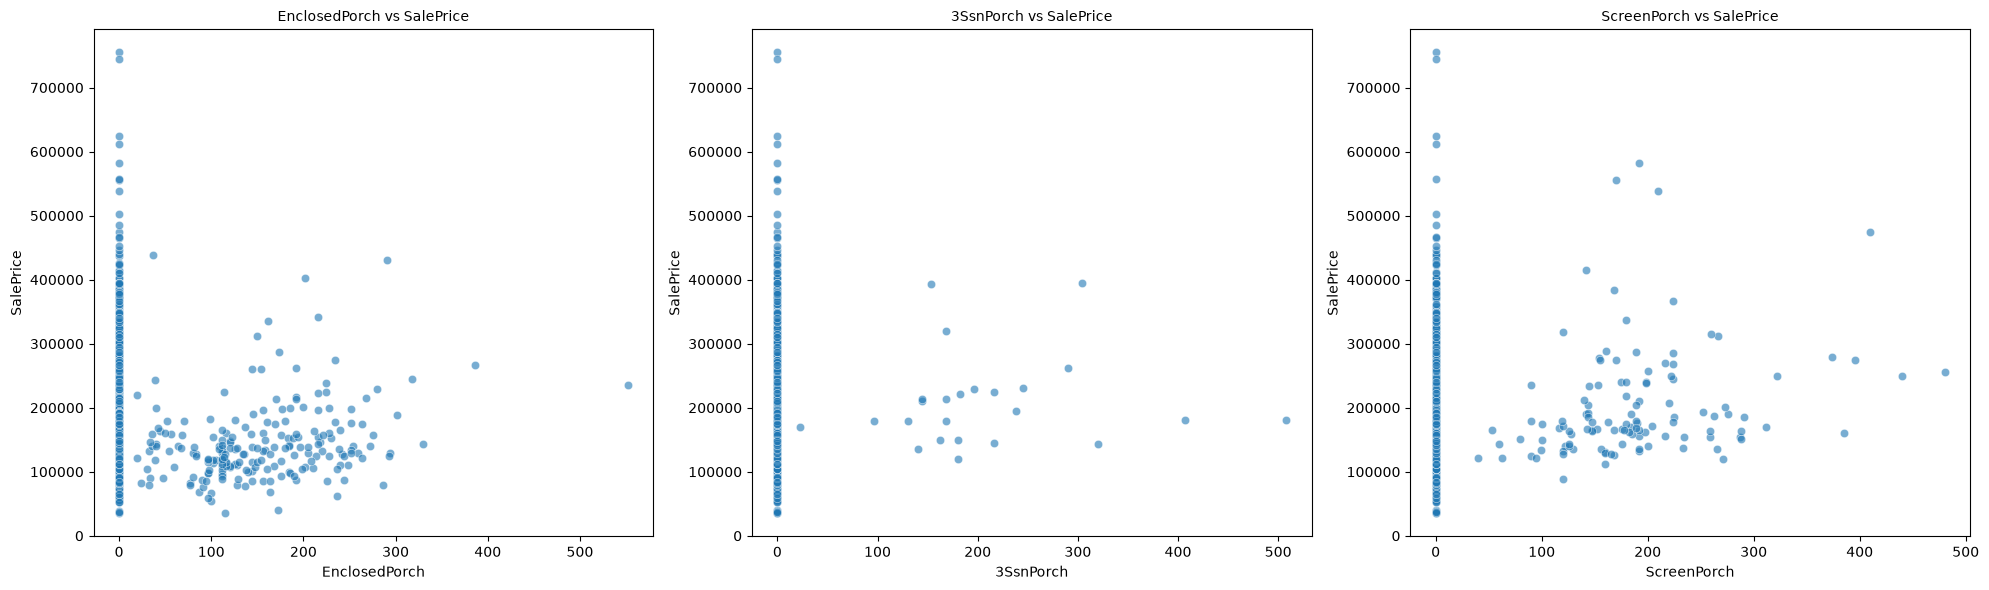

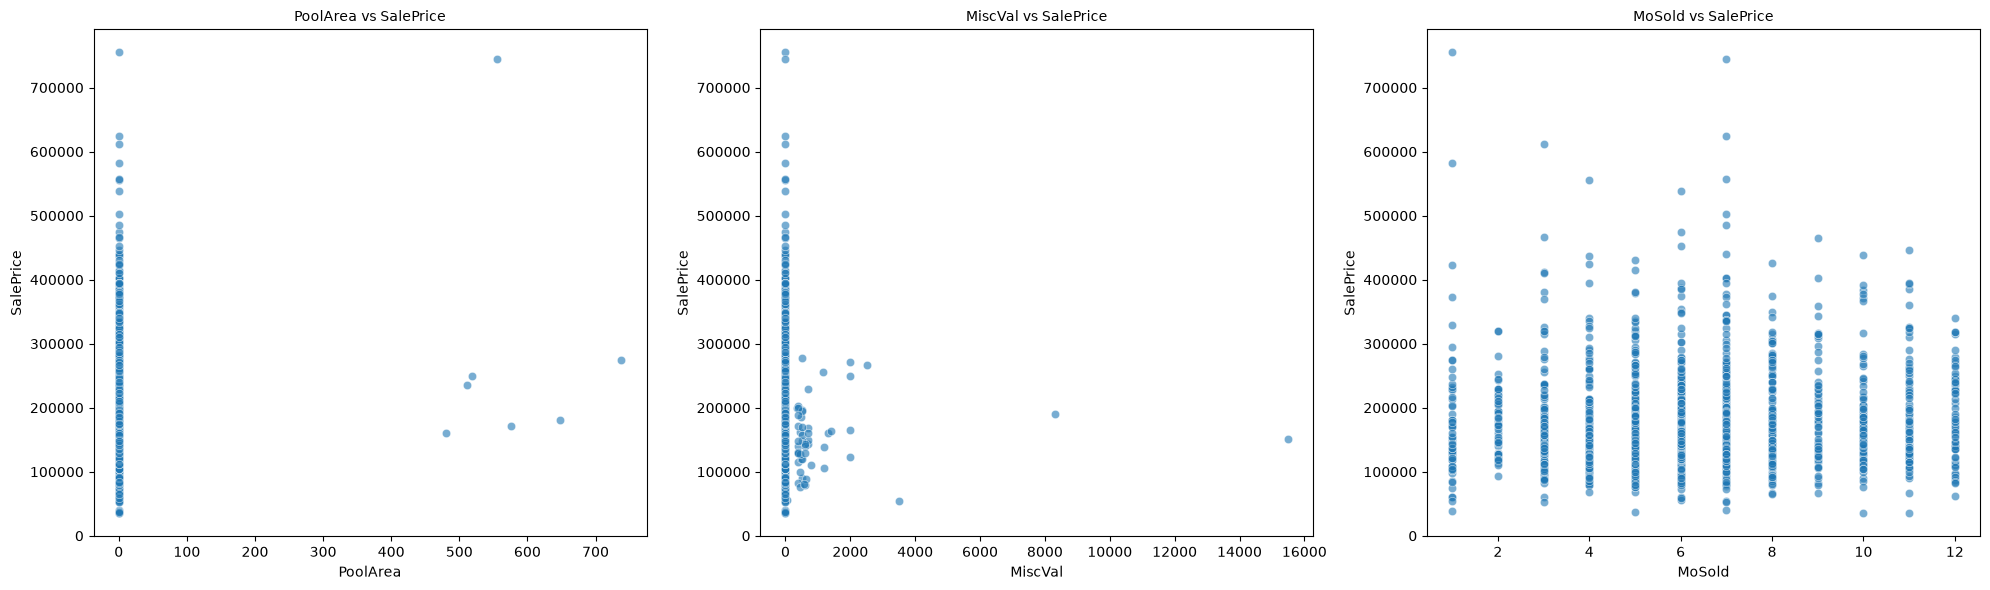

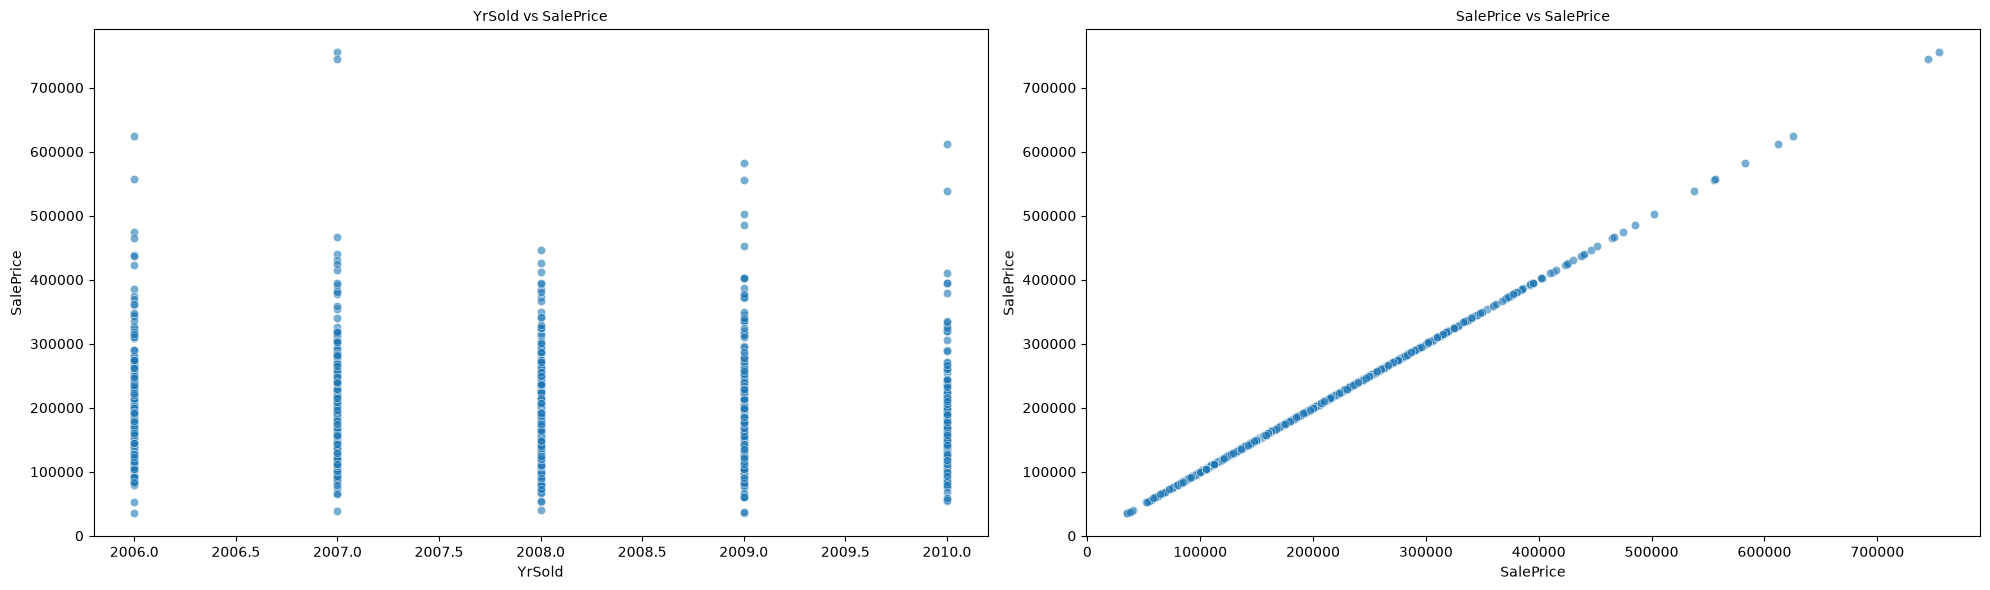

In [26]:
all_columns_with_price(train_data)


In [27]:
def var_vs_price( var ):
    plt.figure(figsize=(9 , 5))
    plt.scatter( data= train_data , x = var , y = 'SalePrice')
    plt.show()

##### LotFrontage

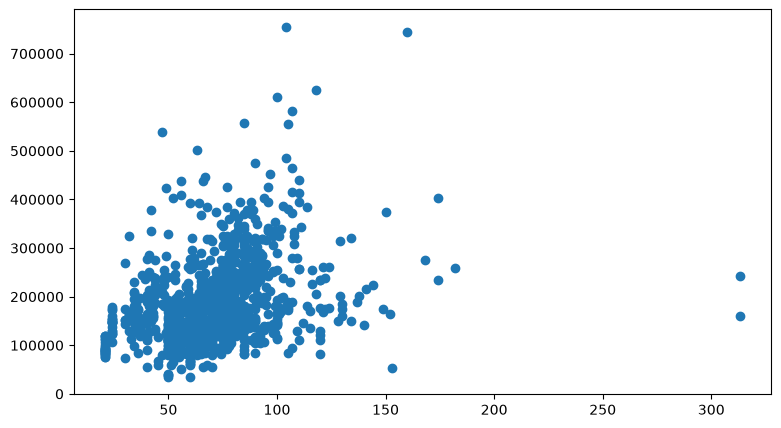

In [28]:
var_vs_price('LotFrontage')

In [29]:
outliers_to_check = train_data.loc[ 
    train_data['LotFrontage'] > 300 , 
['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice'] 
                                   ]
outliers_to_check

,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
934,313.0,27650,2069,7,1960,242000
1298,313.0,63887,5642,10,2008,160000


In [30]:
train_data = train_data.drop(index = 1298 , axis = 0 )
1298 in train_data.index

False

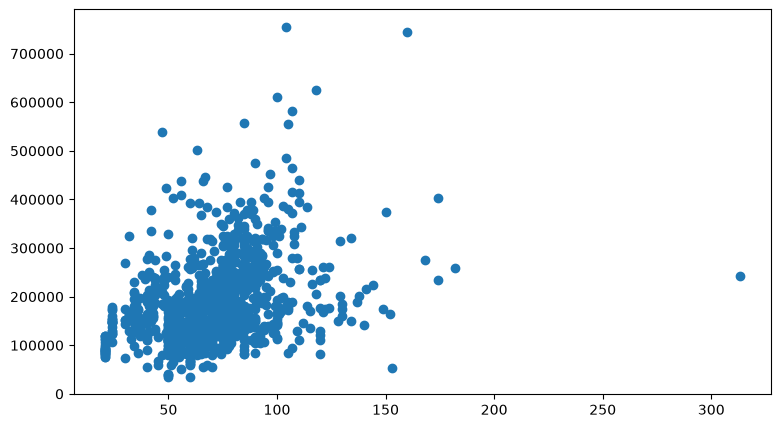

In [31]:
var_vs_price('LotFrontage')

##### LotArea


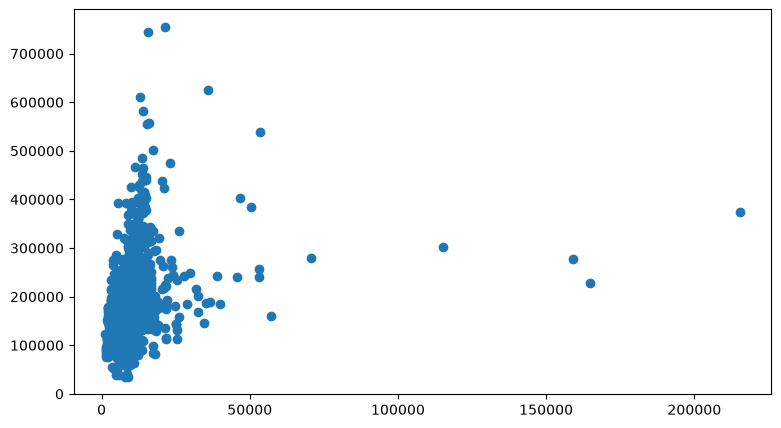

In [32]:
var_vs_price('LotArea')

In [33]:
outliers_to_check = train_data.loc[train_data['LotArea'] > 100000 , 
['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice'] 
                                 ]
outliers_to_check

,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
249,NaN,159000,2144,6,1958,277000
313,150.0,215245,2036,7,1965,375000
335,NaN,164660,1786,5,1965,228950
706,NaN,115149,1824,7,1971,302000


#### MasVnrArea

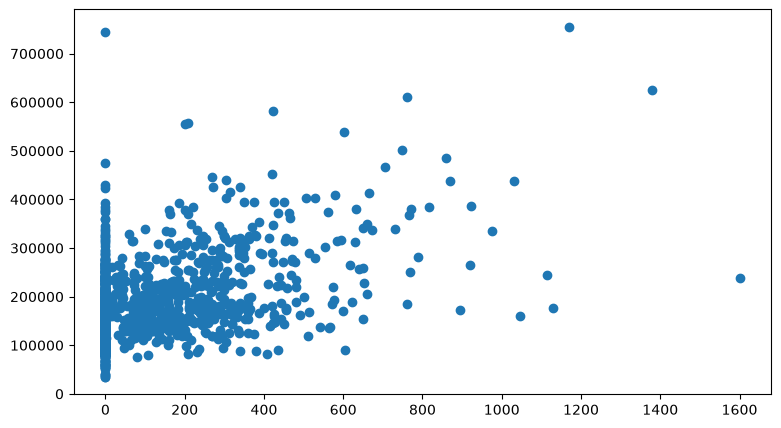

In [34]:
var_vs_price('MasVnrArea')

In [35]:
outliers_to_check = train_data.loc[
(train_data['MasVnrArea'] > 1500) &( train_data['SalePrice'] < 300000 ) , 
['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice'] 
]
outliers_to_check

,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
297,66.0,7399,1950,7,1997,239000


#### BsmtFinSF1


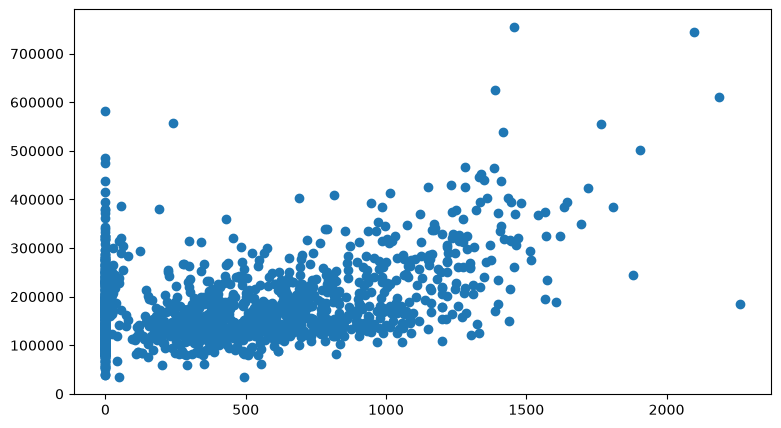

In [36]:
var_vs_price('BsmtFinSF1')

In [37]:
outliers_to_check = train_data.loc[ 
( train_data['BsmtFinSF1'] > 2000 ) & ( train_data['SalePrice'] < 250000),
['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice'] 
                                  ] 

outliers_to_check

,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
523,130.0,40094,4676,10,2007,184750


In [38]:
train_data = train_data.drop(523 , axis = 0 )
523 in train_data.index

False

#### BsmtFinSF2

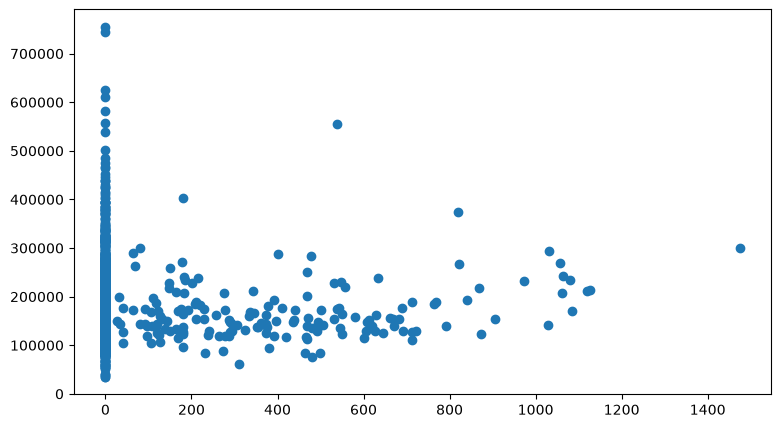

In [39]:
var_vs_price('BsmtFinSF2')

In [40]:
outliers_to_check = train_data.loc[
    train_data['BsmtFinSF2'] > 1400 , 
    ['LotFrontage', 'LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice']
]
outliers_to_check

,LotFrontage,LotArea,GrLivArea,OverallQual,YearBuilt,SalePrice
322,86.0,10380,2730,7,1986,301000


#### BsmtUnfSF

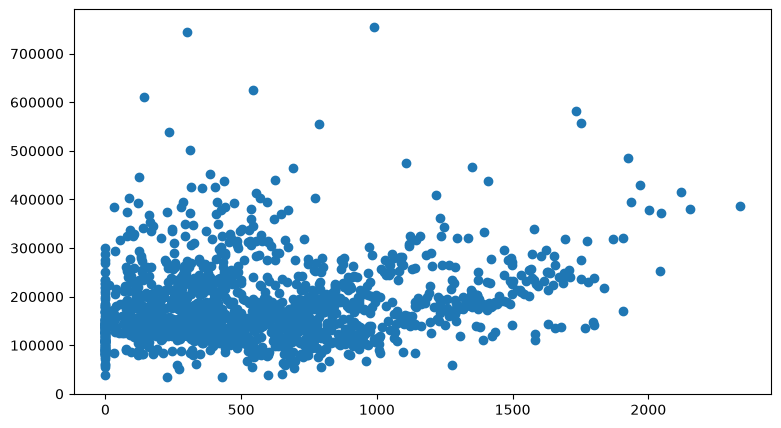

In [41]:
var_vs_price('BsmtUnfSF')

#### TotalBsmtSF

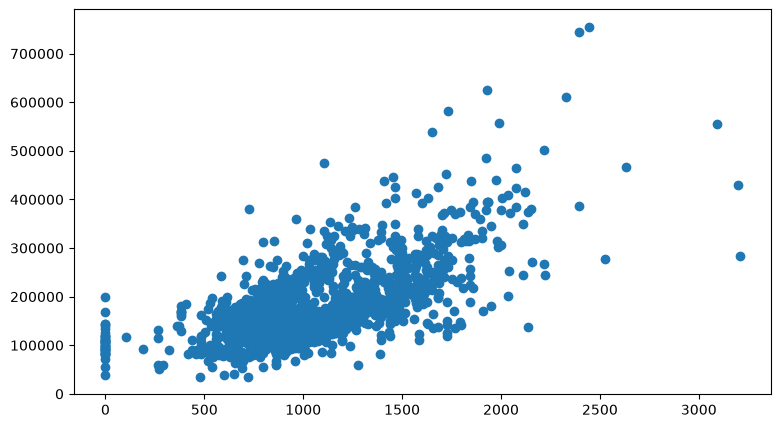

In [42]:
var_vs_price('TotalBsmtSF')

In [43]:
# after removing outliers , reseting indices
train_data = train_data.reset_index(drop=True) # drop=True <> don't save the old index
print("Data shape after removing outliers:", train_data.shape)

Data shape after removing outliers: (1458, 76)


### Nulls

In [44]:
nulls = train_data.isnull().sum()
nulls = nulls[ nulls > 0 ]
nulls

LotFrontage     259
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

##### Handling with Categorical Columns

In [ ]:
cat_cols_nulls = train_data[nulls.index].select_dtypes(
     include=['category' , 'object']).isnull().sum()

cat_cols_nulls = cat_cols_nulls[ cat_cols_nulls > 0 ]   
cat_cols_nulls

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
Electrical       1
GarageType      81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

In [46]:
cat_cols_nulls_names = train_data[nulls.index].select_dtypes(
    include=['string' , 'object']).columns
                                                            
cat_cols_nulls_names

Index(['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'],
      dtype='str')

In [47]:
cat_cols_nulls_names = cat_cols_nulls_names.difference(['Electrical'])
cat_cols_nulls_names

Index(['BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual',
       'GarageCond', 'GarageFinish', 'GarageQual', 'GarageType'],
      dtype='str')

In [48]:
train_data[cat_cols_nulls_names] = train_data[cat_cols_nulls_names].fillna('Missing')

In [49]:
train_data['Electrical'] = train_data['Electrical'].fillna(
          train_data['Electrical'].mode()[0])

In [50]:
nulls = train_data.isnull().sum()
nulls = nulls[nulls > 0]
nulls

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

##### Handling with Numerical Columns

In [51]:
num_cols_nulls = train_data[nulls.index].select_dtypes(include = np.number).isnull().sum()
num_cols_nulls

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [52]:
num_cols_names = train_data[nulls.index].select_dtypes(include=np.number).columns
num_cols_names = num_cols_names.drop('GarageYrBlt')
num_cols_names

Index(['LotFrontage', 'MasVnrArea'], dtype='str')

In [53]:
train_data['GarageYrBlt'] = train_data['GarageYrBlt'].fillna(0)

train_data[num_cols_names] = train_data[num_cols_names].fillna(
    train_data[num_cols_names].median() )

train_data.isnull().sum().sum()

np.int64(0)

In [ ]:
train_data['PoolQC'].value_counts()

0       Missing
1       Missing
2       Missing
3       Missing
4       Missing
5       Missing
6       Missing
7       Missing
8       Missing
9       Missing
10      Missing
11      Missing
12      Missing
13      Missing
14      Missing
15      Missing
16      Missing
17      Missing
18      Missing
19      Missing
20      Missing
21      Missing
22      Missing
23      Missing
24      Missing
25      Missing
26      Missing
27      Missing
28      Missing
29      Missing
30      Missing
31      Missing
32      Missing
33      Missing
34      Missing
35      Missing
36      Missing
37      Missing
38      Missing
39      Missing
40      Missing
41      Missing
42      Missing
43      Missing
44      Missing
45      Missing
46      Missing
47      Missing
48      Missing
49      Missing
50      Missing
51      Missing
52      Missing
53      Missing
54      Missing
55      Missing
56      Missing
57      Missing
58      Missing
59      Missing
60      Missing
61      Missing
62      

#### Visualize SalePrice & GrLivArea Distribution

Text(0.5, 1.0, 'GrLivArea Distribution')

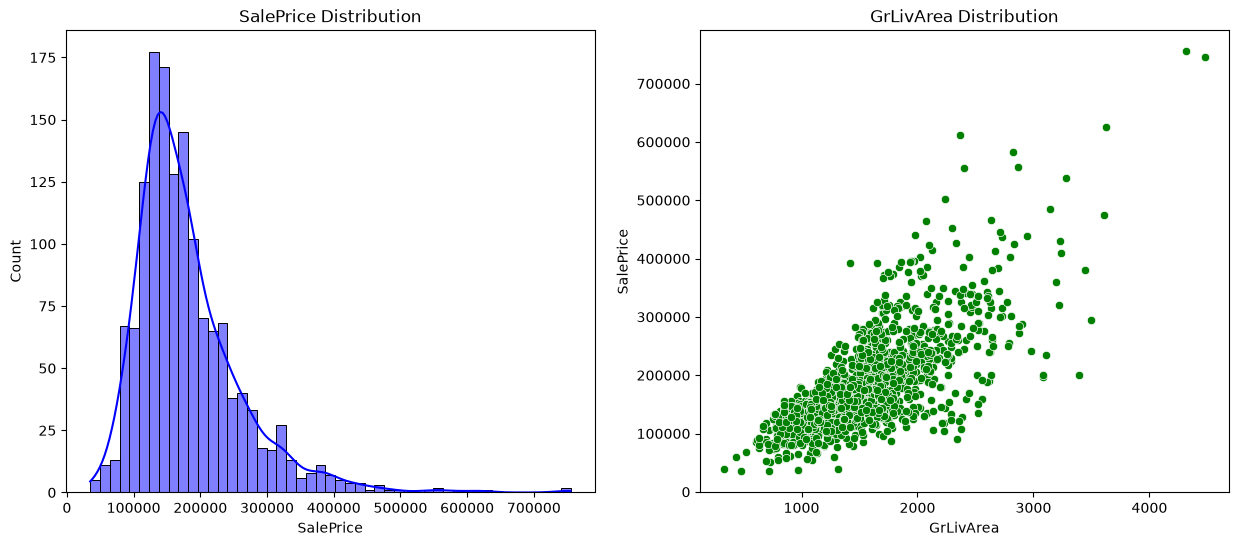

In [55]:
fig , ax = plt.subplots( 1 , 2 , figsize=(15 , 6))

sns.histplot(data= train_data , x= 'SalePrice', kde=True , ax=ax[0], color = 'blue')
ax[0].set_title('SalePrice Distribution')

sns.scatterplot( data= train_data , x= 'GrLivArea',  y='SalePrice',ax=ax[1], color = 'green')
ax[1].set_title('GrLivArea Distribution')



Text(0.5, 1.0, 'SalePrice Distribution after(Log1p Trans)')

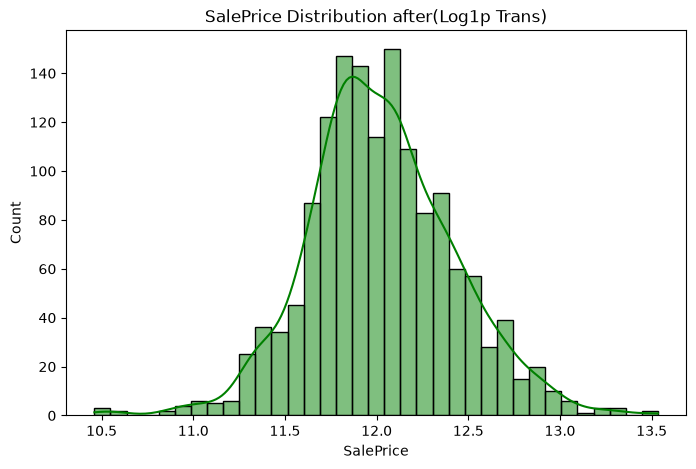

In [56]:
train_data['SalePrice'] = np.log1p(train_data['SalePrice'])

plt.figure(figsize=(8 , 5))
sns.histplot(train_data['SalePrice'], kde=True , color = 'green')
plt.title('SalePrice Distribution after(Log1p Trans)')

In [57]:
train_data.to_csv('../datasets/processed/cleaned_train_data.csv', index = False )